## English Teacher Model

Read xlsx, create pandas dataframe, select definition of each tactics, embed by LLM, and save to csv

In [1]:
import plotly.io as pio

pio.renderers.default = "vscode" # for vscode coding
#pio.renderers.default = "notebook" # for github.io rendering

# python version check
import sys
print(f"Python version: {sys.version}")

Python version: 3.11.15 (main, Mar 11 2026, 17:14:47) [Clang 20.1.8 ]


In [ ]:
tactics_file = "enterprise-attack-v19.1-tactics.xlsx"
techniques_file = "enterprise-attack-v19.1-techniques.xlsx"

tactics_embeddings_file = "tactics_embeddings.csv"
techniques_embeddings_file = "techniques_embeddings.csv"

llm_model = "nomic-ai/nomic-embed-text-v2-moe"

threshold = 0.50

In [3]:
# test gpu, tpu
import torch

device = "cpu"
if torch.cuda.is_available():
    print("GPU is available")
    device = "cuda"
elif torch.backends.mps.is_available():
    print("Apple Silicon GPU is available")
    device = "mps"

print(f"Using device: {device}")

Apple Silicon GPU is available
Using device: mps


In [4]:
import pandas as pd
import numpy as np
tactics_df = pd.read_excel(tactics_file, engine='openpyxl')
tactics_df.sort_values(by='ID', inplace=True)

tactics_df.head()

,ID,STIX ID,name,description,url,created,last modified,domain,version
8,TA0001,x-mitre-tactic--ffd5bcee-6e16-4dd2-8eca-7b3bee...,Initial Access,The adversary is trying to get into your netwo...,https://attack.mitre.org/tactics/TA0001,17 October 2018,25 April 2025,enterprise-attack,1.0
5,TA0002,x-mitre-tactic--4ca45d45-df4d-4613-8980-bac22d...,Execution,The adversary is trying to run malicious code....,https://attack.mitre.org/tactics/TA0002,17 October 2018,25 April 2025,enterprise-attack,1.0
10,TA0003,x-mitre-tactic--5bc1d813-693e-4823-9961-abf9af...,Persistence,The adversary is trying to maintain their foot...,https://attack.mitre.org/tactics/TA0003,17 October 2018,25 April 2025,enterprise-attack,1.0
11,TA0004,x-mitre-tactic--5e29b093-294e-49e9-a803-dab3d7...,Privilege Escalation,The adversary is trying to gain higher-level p...,https://attack.mitre.org/tactics/TA0004,17 October 2018,25 April 2025,enterprise-attack,1.0
14,TA0005,x-mitre-tactic--78b23412-0651-46d7-a540-170a1c...,Stealth,The adversary is trying to hide and conceal th...,https://attack.mitre.org/tactics/TA0005,17 October 2018,12 May 2026,enterprise-attack,1.0


In [157]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer(llm_model, trust_remote_code=True, device = device)
#tactics_df['embedding'] = tactics_df['description'].apply(lambda x: model.encode(x).tolist())
tactics_df["embedding"] = [
    model.encode(x, convert_to_numpy=True).astype(np.float32)
    for x in tactics_df["description"]
]
tactics_df.head()

/Users/hsiaom/.cache/huggingface/modules/transformers_modules/nomic_hyphen_ai/nomic_hyphen_bert_hyphen_2048/7710840340a098cfb869c4f65e87cf2b1b70caca/modeling_hf_nomic_bert.py:1634: UserWarning: Install Nomic's megablocks fork for better speed: `pip install git+https://github.com/nomic-ai/megablocks.git`
  warnings.warn("Install Nomic's megablocks fork for better speed: " +


,ID,STIX ID,name,description,url,created,last modified,domain,version,embedding
8,TA0001,x-mitre-tactic--ffd5bcee-6e16-4dd2-8eca-7b3bee...,Initial Access,The adversary is trying to get into your netwo...,https://attack.mitre.org/tactics/TA0001,17 October 2018,25 April 2025,enterprise-attack,1.0,"[0.06018931, 0.0038062967, -0.041318342, 0.019..."
5,TA0002,x-mitre-tactic--4ca45d45-df4d-4613-8980-bac22d...,Execution,The adversary is trying to run malicious code....,https://attack.mitre.org/tactics/TA0002,17 October 2018,25 April 2025,enterprise-attack,1.0,"[0.05460806, 0.009688934, -0.042434752, -0.018..."
10,TA0003,x-mitre-tactic--5bc1d813-693e-4823-9961-abf9af...,Persistence,The adversary is trying to maintain their foot...,https://attack.mitre.org/tactics/TA0003,17 October 2018,25 April 2025,enterprise-attack,1.0,"[0.055283684, 0.022326812, -0.019933276, -0.04..."
11,TA0004,x-mitre-tactic--5e29b093-294e-49e9-a803-dab3d7...,Privilege Escalation,The adversary is trying to gain higher-level p...,https://attack.mitre.org/tactics/TA0004,17 October 2018,25 April 2025,enterprise-attack,1.0,"[0.05832777, -0.024653304, -0.016843088, -0.01..."
14,TA0005,x-mitre-tactic--78b23412-0651-46d7-a540-170a1c...,Stealth,The adversary is trying to hide and conceal th...,https://attack.mitre.org/tactics/TA0005,17 October 2018,12 May 2026,enterprise-attack,1.0,"[-0.014206556, -0.0058423723, -0.03413514, -0...."


In [158]:

# umap visualization
import umap

umap_model = umap.UMAP(n_neighbors=5, n_components=3, metric='cosine', n_jobs=-1, random_state=42)
embedding_3d = umap_model.fit_transform(list(tactics_df['embedding']))

/opt/miniconda3/envs/py311/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [159]:
# plot
import plotly.express as px
import plotly.io as pio
import matplotlib.cm as cm

fig = px.scatter_3d(
    embedding_3d,
    x=0,
    y=1,
    z=2,
    hover_data={'name': tactics_df['name'], 'ID': tactics_df['ID']},
    color = list(range(len(tactics_df))),
)
fig.update_layout(title='Tactics Embeddings UMAP Visualization')
fig.show()

In [160]:
# use tactics_df['embedding'] as the bases
teacher_vectors = torch.from_numpy(
    np.stack(tactics_df["embedding"].values)
).to("mps", dtype=torch.float32)

teacher_vectors_labels = tactics_df['name'].tolist()

In [161]:
teacher_vectors.shape

torch.Size([15, 768])

In [162]:
print(torch.linalg.matrix_rank(teacher_vectors.to("cpu"))) # but we use the original embeddings
print(teacher_vectors.shape) # but we use the original embeddings, not the projected ones, for similarity calculation

tensor(15)
torch.Size([15, 768])


In [163]:
import torch
import torch.nn.functional as F

norm_ = F.normalize(teacher_vectors, p=2, dim=1)
cos_sim_matrix = torch.mm(norm_, norm_.t())
cos_sim_matrix = cos_sim_matrix.detach().cpu().numpy()

# cos_sim_matrix, draw
cos_df = pd.DataFrame(cos_sim_matrix, columns=teacher_vectors_labels, index=teacher_vectors_labels)
cos_df.style.background_gradient(cmap="Reds", axis=None).format(precision=2)

,Initial Access,Execution,Persistence,Privilege Escalation,Stealth,Credential Access,Discovery,Lateral Movement,Collection,Exfiltration,Command and Control,Impact,Resource Development,Reconnaissance,Defense Impairment
Initial Access,1.00,0.54,0.62,0.58,0.43,0.60,0.50,0.59,0.49,0.54,0.53,0.52,0.56,0.52,0.46
Execution,0.54,1.00,0.60,0.56,0.52,0.53,0.64,0.64,0.56,0.60,0.65,0.62,0.62,0.53,0.52
Persistence,0.62,0.60,1.00,0.64,0.51,0.58,0.55,0.59,0.48,0.51,0.56,0.59,0.58,0.53,0.54
Privilege Escalation,0.58,0.56,0.64,1.00,0.43,0.54,0.51,0.58,0.44,0.54,0.53,0.48,0.51,0.44,0.45
Stealth,0.43,0.52,0.51,0.43,1.00,0.52,0.47,0.48,0.50,0.55,0.61,0.48,0.49,0.51,0.59
Credential Access,0.60,0.53,0.58,0.54,0.52,1.00,0.46,0.58,0.53,0.56,0.52,0.52,0.56,0.48,0.46
Discovery,0.50,0.64,0.55,0.51,0.47,0.46,1.00,0.62,0.62,0.54,0.61,0.56,0.61,0.69,0.51
Lateral Movement,0.59,0.64,0.59,0.58,0.48,0.58,0.62,1.00,0.51,0.54,0.61,0.50,0.54,0.48,0.50
Collection,0.49,0.56,0.48,0.44,0.50,0.53,0.62,0.51,1.00,0.67,0.51,0.57,0.57,0.65,0.44
Exfiltration,0.54,0.60,0.51,0.54,0.55,0.56,0.54,0.54,0.67,1.00,0.57,0.59,0.53,0.53,0.47


## Technique Article

In [164]:
techniques_df = pd.read_excel(techniques_file, engine='openpyxl')
techniques_df.sort_values(by='ID', inplace=True)

techniques_df.head()

,ID,STIX ID,name,description,url,created,last modified,domain,version,tactics,platforms,is sub-technique,sub-technique of,contributors,supports remote,impact type,relationship citations
157,T1001,attack-pattern--ad255bfe-a9e6-4b52-a258-8d3462...,Data Obfuscation,Adversaries may obfuscate command and control ...,https://attack.mitre.org/techniques/T1001,31 May 2017,12 May 2026,enterprise-attack,1.2,Command and Control,"ESXi, Linux, Windows, macOS",False,NaN,NaN,NaN,NaN,"(Citation: ESET Okrum July 2019),(Citation: Ch..."
158,T1001.001,attack-pattern--f7c0689c-4dbd-489b-81be-7cb7c7...,Data Obfuscation: Junk Data,Adversaries may add junk data to protocols use...,https://attack.mitre.org/techniques/T1001/001,15 March 2020,12 May 2026,enterprise-attack,1.1,Command and Control,"ESXi, Linux, Windows, macOS",True,T1001,NaN,NaN,NaN,"(Citation: ESET PLEAD Malware July 2018),(Cita..."
160,T1001.002,attack-pattern--eec23884-3fa1-4d8a-ac50-6f104d...,Data Obfuscation: Steganography,Adversaries may use steganographic techniques ...,https://attack.mitre.org/techniques/T1001/002,15 March 2020,24 October 2025,enterprise-attack,1.1,Command and Control,"ESXi, Linux, Windows, macOS",True,T1001,NaN,NaN,NaN,"(Citation: GitHub Sliver HTTP),(Citation: Fire..."
159,T1001.003,attack-pattern--c325b232-d5bc-4dde-a3ec-71f3db...,Data Obfuscation: Protocol or Service Imperson...,Adversaries may impersonate legitimate protoco...,https://attack.mitre.org/techniques/T1001/003,15 March 2020,12 May 2026,enterprise-attack,2.1,Command and Control,"ESXi, Linux, Windows, macOS",True,T1001,"James Emery-Callcott, Emerging Threats Team, P...",NaN,NaN,(Citation: McAfee Lazarus Resurfaces Feb 2018)...
422,T1003,attack-pattern--0a3ead4e-6d47-4ccb-854c-a6a4f9...,OS Credential Dumping,Adversaries may attempt to dump credentials to...,https://attack.mitre.org/techniques/T1003,31 May 2017,24 October 2025,enterprise-attack,2.2,Credential Access,"Linux, Windows, macOS",False,NaN,"Ed Williams, Trustwave, SpiderLabs; Tim (Wadhw...",NaN,NaN,(Citation: Microsoft Storm-501 Sabbath Ransomw...


In [165]:
# get some random techniques, embed them using the same model as tactics_df 

techniques_rnd_df = techniques_df.sample(100, random_state=42).copy()
techniques_rnd_df["embedding"] = [
    model.encode(x, convert_to_numpy=True).astype(np.float32)
    for x in techniques_rnd_df["description"]
]
techniques_rnd_df.head()

,ID,STIX ID,name,description,url,created,last modified,domain,version,tactics,platforms,is sub-technique,sub-technique of,contributors,supports remote,impact type,relationship citations,embedding
677,T1078.004,attack-pattern--f232fa7a-025c-4d43-abc7-318e81...,Valid Accounts: Cloud Accounts,Valid accounts in cloud environments may allow...,https://attack.mitre.org/techniques/T1078/004,13 March 2020,12 May 2026,enterprise-attack,2.0,"Initial Access, Persistence, Privilege Escalat...","IaaS, Identity Provider, Office Suite, SaaS",True,T1078,"Alon Klayman, Hunters Security; Arun Seelagan,...",NaN,NaN,(Citation: Crowdstrike TELCO BPO Campaign Dece...,"[0.039309785, 0.0049542394, -0.032674585, -0.0..."
271,T1567.001,attack-pattern--86a96bf6-cf8b-411c-aaeb-895994...,Exfiltration Over Web Service: Exfiltration to...,Adversaries may exfiltrate data to a code repo...,https://attack.mitre.org/techniques/T1567/001,09 March 2020,12 May 2026,enterprise-attack,1.2,Exfiltration,"ESXi, Linux, Windows, macOS",True,T1567,NaN,NaN,NaN,(Citation: Socket Shai-Hulud Trufflehog Septem...,"[0.032600082, 0.047567297, -0.00029166468, -0...."
73,T1547.009,attack-pattern--4ab929c6-ee2d-4fb5-aab4-b14be2...,Boot or Logon Autostart Execution: Shortcut Mo...,Adversaries may create or modify shortcuts tha...,https://attack.mitre.org/techniques/T1547/009,24 January 2020,24 October 2025,enterprise-attack,1.3,"Persistence, Privilege Escalation",Windows,True,T1547,"Bobby, Filar, Elastic; David French, Elastic; ...",NaN,NaN,"(Citation: FireEye APT39 Jan 2019),(Citation: ...","[0.05314307, 0.030829428, -0.0001165708, -0.04..."
678,T1078.001,attack-pattern--6151cbea-819b-455a-9fa6-99a1cc...,Valid Accounts: Default Accounts,Adversaries may obtain and abuse credentials o...,https://attack.mitre.org/techniques/T1078/001,13 March 2020,12 May 2026,enterprise-attack,2.0,"Initial Access, Persistence, Privilege Escalat...","Containers, ESXi, IaaS, Identity Provider, Lin...",True,T1078,Janantha Marasinghe,NaN,NaN,"(Citation: DFIR Phosphorus November 2021),(Cit...","[0.02491305, 0.01514199, -0.04690796, -0.04419..."
534,T1496.004,attack-pattern--924d273c-be0d-4d8d-af58-2dddb1...,Resource Hijacking: Cloud Service Hijacking,Adversaries may leverage compromised software-...,https://attack.mitre.org/techniques/T1496/004,25 September 2024,15 April 2025,enterprise-attack,1.0,Impact,SaaS,True,T1496,NaN,NaN,Availability,",,","[0.057533383, 0.018849125, -0.016497169, -0.01..."


## English Model Eval

In [166]:
all_techniques_np = np.stack(techniques_rnd_df["embedding"].values)
all_techniques = torch.from_numpy(all_techniques_np).to(
    "mps", dtype=torch.float32
)
norm_techniques = F.normalize(all_techniques, p=2, dim=1)  # (N, 768)
norm_teachers = F.normalize(teacher_vectors, p=2, dim=1)  # (15, 768)
cos_sim_matrix_gpu = torch.mm(norm_techniques, norm_teachers.t())
cos_sim_matrix = cos_sim_matrix_gpu.cpu().numpy()

orig_columns = [label for label in teacher_vectors_labels]
cos_sim_orig_df = pd.DataFrame(cos_sim_matrix, columns=orig_columns)

techniques_rnd_df["closest_tactic"] = [
    teacher_vectors_labels[idx] for idx in np.argmax(cos_sim_matrix, axis=1)
]

techniques_rnd_df = techniques_rnd_df.reset_index(drop=True)
cos_sim_orig_df = cos_sim_orig_df.reset_index(drop=True)

techniques_rnd_df = pd.concat([techniques_rnd_df, cos_sim_orig_df], axis=1)


In [167]:
techniques_rnd_df["match"] = techniques_rnd_df.apply(
    lambda row: str(row["closest_tactic"]) in str(row["tactics"]), axis=1
)

In [168]:
techniques_rnd_df[["ID", "name", "closest_tactic", "tactics", "match"] + teacher_vectors_labels]

,ID,name,closest_tactic,tactics,match,Initial Access,Execution,Persistence,Privilege Escalation,Stealth,Credential Access,Discovery,Lateral Movement,Collection,Exfiltration,Command and Control,Impact,Resource Development,Reconnaissance,Defense Impairment
0,T1078.004,Valid Accounts: Cloud Accounts,Privilege Escalation,"Initial Access, Persistence, Privilege Escalat...",True,0.50,0.48,0.56,0.58,0.35,0.52,0.45,0.47,0.38,0.41,0.43,0.51,0.54,0.44,0.40
1,T1567.001,Exfiltration Over Web Service: Exfiltration to...,Exfiltration,Exfiltration,True,0.45,0.56,0.50,0.49,0.36,0.41,0.44,0.42,0.46,0.62,0.46,0.42,0.48,0.42,0.36
2,T1547.009,Boot or Logon Autostart Execution: Shortcut Mo...,Persistence,"Persistence, Privilege Escalation",True,0.49,0.58,0.69,0.53,0.40,0.44,0.50,0.50,0.44,0.43,0.47,0.55,0.51,0.43,0.40
3,T1078.001,Valid Accounts: Default Accounts,Persistence,"Initial Access, Persistence, Privilege Escalat...",True,0.57,0.51,0.60,0.58,0.40,0.58,0.47,0.51,0.42,0.45,0.47,0.50,0.54,0.42,0.43
4,T1496.004,Resource Hijacking: Cloud Service Hijacking,Impact,Impact,True,0.44,0.51,0.47,0.43,0.37,0.43,0.43,0.46,0.40,0.45,0.46,0.55,0.52,0.42,0.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,T1573.002,Encrypted Channel: Asymmetric Cryptography,Command and Control,Command and Control,True,0.41,0.49,0.43,0.42,0.46,0.44,0.42,0.44,0.45,0.51,0.56,0.45,0.43,0.41,0.43
96,T1648,Serverless Execution,Execution,Execution,True,0.45,0.61,0.55,0.53,0.39,0.46,0.48,0.47,0.42,0.47,0.48,0.54,0.56,0.41,0.45
97,T1200,Hardware Additions,Resource Development,Initial Access,False,0.57,0.56,0.55,0.52,0.43,0.50,0.54,0.57,0.50,0.52,0.53,0.54,0.58,0.50,0.49
98,T1127.001,Trusted Developer Utilities Proxy Execution: M...,Execution,"Execution, Stealth",True,0.31,0.55,0.39,0.37,0.26,0.33,0.40,0.37,0.35,0.34,0.37,0.38,0.43,0.29,0.30


In [169]:
techniques_rnd_df.match.value_counts()

match
True     52
False    48
Name: count, dtype: int64

## Expert Model (Original Vectoers as Anchors)

In [107]:
expert_subspace = teacher_vectors.to("mps", dtype=torch.float32)

In [193]:
import numpy as np
import torch
import torch.nn.functional as F


def lambda_closest_tactic_subspace_proj(x):
    x_tensor_cpu = torch.from_numpy(x).to("cpu", dtype=torch.float32).view(768, 1)

    # 將專家子空間拉到 CPU 轉置作為基底 -> 形狀 (768, 15)
    U_cpu = expert_subspace.to("cpu").t()

    # 在 CPU 上進行正交投影求解 (最小平方法)
    solution_cpu = torch.linalg.lstsq(U_cpu, x_tensor_cpu).solution

    # 安全降維成一維 (768,) 並送回 GPU (MPS)
    x_projected = torch.mm(U_cpu, solution_cpu).view(768).to("mps")

    # 在 GPU 超平面世界中，計算 Cosine Similarity
    norm_x_proj = F.normalize(x_projected.view(1, 768), p=2, dim=1)
    norm_expert = F.normalize(expert_subspace, p=2, dim=1)

    # 矩陣相乘 (1, 768) mm (768, 15) -> 壓縮成一維 (15,)
    cos_sim = torch.mm(norm_x_proj, norm_expert.t()).view(15)

    # 回傳 15 個分數的 NumPy 陣列
    return cos_sim.cpu().numpy()

def lambda_closest_tactic_subspace_proj_p(x):
    x_tensor_cpu = torch.from_numpy(x).to("cpu", dtype=torch.float32).view(768, 1)

    # 將專家子空間拉到 CPU 轉置作為基底 -> 形狀 (768, 15)
    U_cpu = expert_subspace_p.to("cpu").t()

    # 在 CPU 上進行正交投影求解 (最小平方法)
    solution_cpu = torch.linalg.lstsq(U_cpu, x_tensor_cpu).solution

    # 安全降維成一維 (768,) 並送回 GPU (MPS)
    x_projected = torch.mm(U_cpu, solution_cpu).view(768).to("mps")

    # 在 GPU 超平面世界中，計算 Cosine Similarity
    norm_x_proj = F.normalize(x_projected.view(1, 768), p=2, dim=1)
    norm_expert = F.normalize(expert_subspace_p, p=2, dim=1)

    # 矩陣相乘 (1, 768) mm (768, 15) -> 壓縮成一維 (15,)
    cos_sim = torch.mm(norm_x_proj, norm_expert.t()).view(15)

    # 回傳 15 個分數的 NumPy 陣列
    return cos_sim.cpu().numpy()

In [171]:
# 2. 執行 apply，算出每筆 Technique 投影後的 15 欄分數
techniques_rnd_df["cos_sim_proj"] = techniques_rnd_df["embedding"].apply(
    lambda_closest_tactic_subspace_proj
)

# 3. 轉成 NumPy 矩陣，方便一次性抓出最高分 index
cos_sim_proj_matrix = np.stack(techniques_rnd_df["cos_sim_proj"].values)

# 4. 根據最高分，抓出經過投影純化後的 closest_tactic_proj 標籤名稱
techniques_rnd_df["closest_tactic_proj"] = [
    teacher_vectors_labels[idx] for idx in np.argmax(cos_sim_proj_matrix, axis=1)
]

# 5. 將投影後的 15 個分數拆解成一個獨立的 DataFrame
# 欄位加上 _proj 後綴，與第一部分的原空間分數做出完美區隔
proj_columns_labels = [f"{label}_proj" for label in teacher_vectors_labels]
cos_sim_proj_df = pd.DataFrame(cos_sim_proj_matrix, columns=proj_columns_labels)

# 6. 安全合併欄位 (Reset index 防止 Pandas 索引錯位)
techniques_rnd_df = techniques_rnd_df.reset_index(drop=True)
cos_sim_proj_df = cos_sim_proj_df.reset_index(drop=True)

# 把 15 個帶有 _proj 的子空間分數欄位拼接上去
techniques_rnd_df = pd.concat([techniques_rnd_df, cos_sim_proj_df], axis=1)

# 清理暫存欄位，讓 DataFrame 保持整潔
techniques_rnd_df = techniques_rnd_df.drop(columns=["cos_sim_proj"])

In [173]:
techniques_rnd_df["match_proj"] = techniques_rnd_df.apply(
    lambda row: str(row["closest_tactic_proj"]) in str(row["tactics"]), axis=1
)

In [174]:
techniques_rnd_df[["ID", "name", "closest_tactic", "closest_tactic_proj", "tactics", "match", "match_proj"]]

,ID,name,closest_tactic,closest_tactic_proj,tactics,match,match_proj
0,T1078.004,Valid Accounts: Cloud Accounts,Privilege Escalation,Privilege Escalation,"Initial Access, Persistence, Privilege Escalat...",True,True
1,T1567.001,Exfiltration Over Web Service: Exfiltration to...,Exfiltration,Exfiltration,Exfiltration,True,True
2,T1547.009,Boot or Logon Autostart Execution: Shortcut Mo...,Persistence,Persistence,"Persistence, Privilege Escalation",True,True
3,T1078.001,Valid Accounts: Default Accounts,Persistence,Persistence,"Initial Access, Persistence, Privilege Escalat...",True,True
4,T1496.004,Resource Hijacking: Cloud Service Hijacking,Impact,Impact,Impact,True,True
...,...,...,...,...,...,...,...
95,T1573.002,Encrypted Channel: Asymmetric Cryptography,Command and Control,Command and Control,Command and Control,True,True
96,T1648,Serverless Execution,Execution,Execution,Execution,True,True
97,T1200,Hardware Additions,Resource Development,Resource Development,Initial Access,False,False
98,T1127.001,Trusted Developer Utilities Proxy Execution: M...,Execution,Execution,"Execution, Stealth",True,True


In [175]:
techniques_rnd_df.match_proj.value_counts()

match_proj
True     52
False    48
Name: count, dtype: int64

## Test two approaches

In [176]:
changed_rows = techniques_rnd_df[
    techniques_rnd_df["closest_tactic"] != techniques_rnd_df["closest_tactic_proj"]
]
print(f"分類結果發生改變的 Technique 筆數: {len(changed_rows)}")
print(f"改變比例: {len(changed_rows) / len(techniques_rnd_df) * 100:.2f}%")

分類結果發生改變的 Technique 筆數: 0
改變比例: 0.00%


In [177]:
# 算出原空間與子空間分數的幾何特性變化

import scipy.stats as stats

# 1. 提取原空間與投影空間的 15 欄分數矩陣
# 假設之前合併後的欄位名稱正好是 teacher_vectors_labels 與帶有 _proj 的標籤
orig_scores = techniques_rnd_df[teacher_vectors_labels].values
proj_scores = techniques_rnd_df[proj_columns_labels].values

# 2. 計算每一列（每個 Technique）的分數標準差 (Standard Deviation)
# 標準差越高，代表正確答案越「鶴立雞群」，對比度越高
orig_stds = np.std(orig_scores, axis=1)
proj_stds = np.std(proj_scores, axis=1)

# 3. 計算資訊熵 (Entropy)
# 為了算 Entropy，必須先用 Softmax 將分數轉換為機率分佈
def compute_entropy(scores_matrix):
    # 這裡用一個簡單的 Softmax 歸一化
    exp_scores = np.exp(scores_matrix - np.max(scores_matrix, axis=1, keepdims=True))
    probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
    return stats.entropy(probs.T)

orig_entropies = compute_entropy(orig_scores)
proj_entropies = compute_entropy(proj_scores)

# 4. 將統計指標塞回 DataFrame 方便觀察
techniques_rnd_df['orig_std'] = orig_stds
techniques_rnd_df['proj_std'] = proj_stds
techniques_rnd_df['orig_entropy'] = orig_entropies
techniques_rnd_df['proj_entropy'] = proj_entropies

# === 📊 數據成果量化報告 ===
print("============== 📊 CosSim 分數分佈變化報告 ==============")
print(f"平均原空間分數標準差 (Contrast): {orig_stds.mean():.4f}")
print(f"平均子空間投影標準差 (Contrast): {proj_stds.mean():.4f}")
print(f"📈 對比度提升幅度: {((proj_stds.mean() - orig_stds.mean()) / orig_stds.mean()) * 100:.2f}%")
print("--------------------------------------------------------")
print(f"平均原空間資訊熵 (Uncertainty): {orig_entropies.mean():.4f}")
print(f"平均子空間投影資訊熵 (Uncertainty): {proj_entropies.mean():.4f}")
print(f"📉 不確定性降低幅度: {((orig_entropies.mean() - proj_entropies.mean()) / orig_entropies.mean()) * 100:.2f}%")
print("========================================================")

============== 📊 CosSim 分數分佈變化報告 ==============
平均原空間分數標準差 (Contrast): 0.0557
平均子空間投影標準差 (Contrast): 0.0855
📈 對比度提升幅度: 53.61%
--------------------------------------------------------
平均原空間資訊熵 (Uncertainty): 2.7064
平均子空間投影資訊熵 (Uncertainty): 2.7041
📉 不確定性降低幅度: 0.08%


/var/folders/_r/lwhdpchj7m5cftwpvm8_4bgw0000gn/T/ipykernel_8684/1330666036.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Method', y='Score Spread (Std)', data=df_std, palette="coolwarm")
/var/folders/_r/lwhdpchj7m5cftwpvm8_4bgw0000gn/T/ipykernel_8684/1330666036.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Method', y='Entropy (Uncertainty)', data=df_entropy, palette="coolwarm")


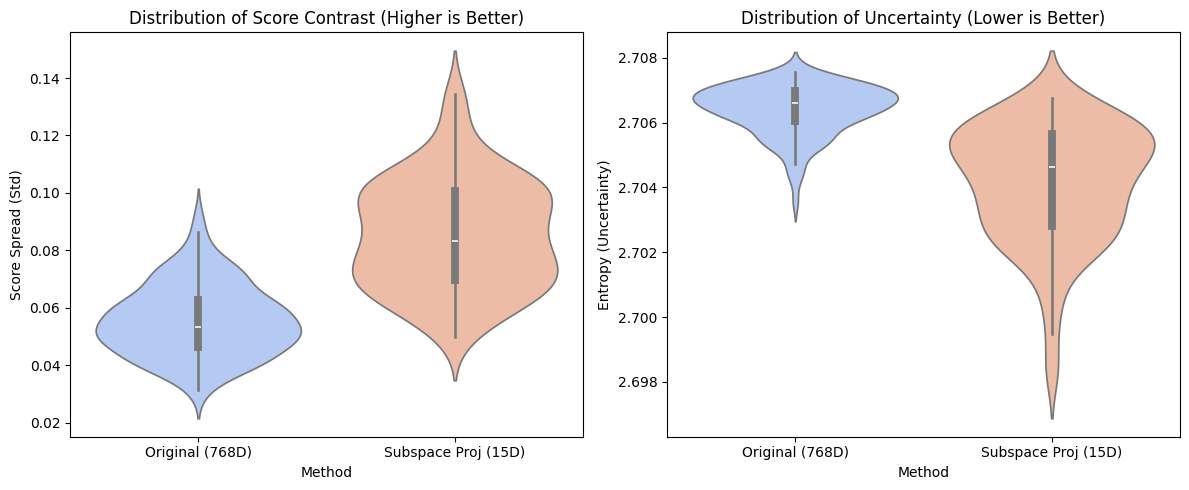

In [179]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# 左圖：標準差對比 (分數有沒有被拉開)
plt.subplot(1, 2, 1)
df_std = pd.DataFrame({
    'Score Spread (Std)': np.concatenate([orig_stds, proj_stds]),
    'Method': ['Original (768D)'] * len(orig_stds) + ['Subspace Proj (15D)'] * len(proj_stds)
})
sns.violinplot(x='Method', y='Score Spread (Std)', data=df_std, palette="coolwarm")
plt.title("Distribution of Score Contrast (Higher is Better)")

# 右圖：資訊熵對比 (決策有沒有變清晰)
plt.subplot(1, 2, 2)
df_entropy = pd.DataFrame({
    'Entropy (Uncertainty)': np.concatenate([orig_entropies, proj_entropies]),
    'Method': ['Original (768D)'] * len(orig_entropies) + ['Subspace Proj (15D)'] * len(proj_entropies)
})
sns.violinplot(x='Method', y='Entropy (Uncertainty)', data=df_entropy, palette="coolwarm")
plt.title("Distribution of Uncertainty (Lower is Better)")

plt.tight_layout()
plt.show()

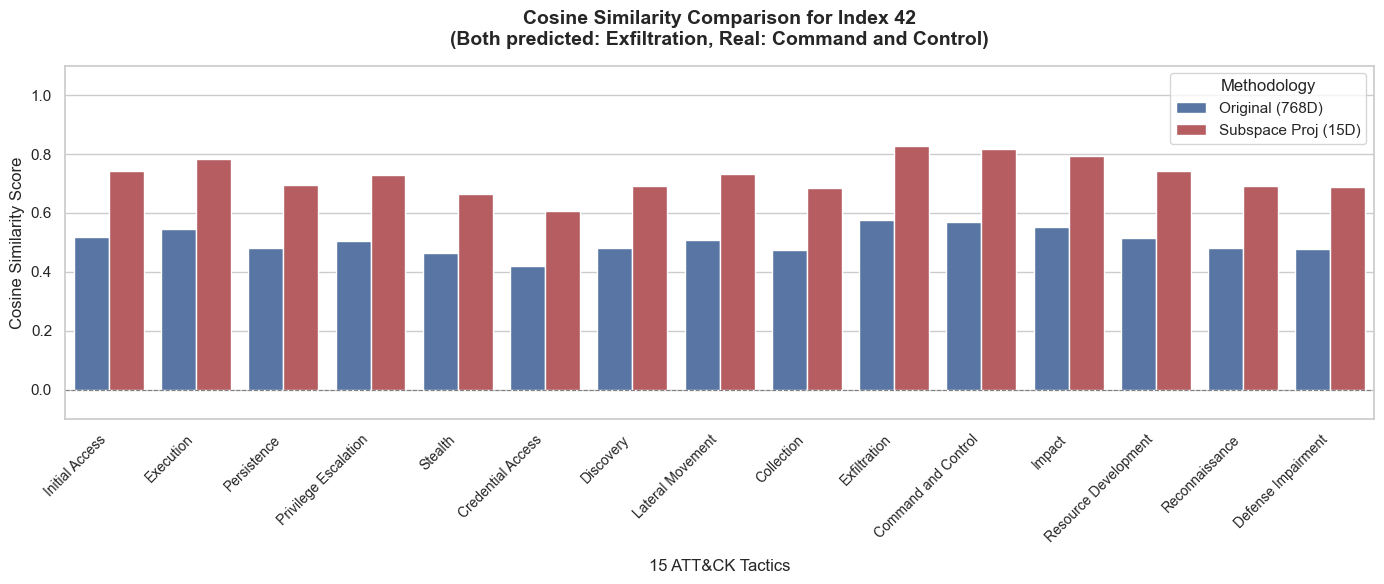

In [188]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ==========================================
# ⚙️ 參數設定：挑選你要觀察的列（Row Index）
# ==========================================
sample_index = 42  # 你可以隨意更換這個 index，看看不同 Technique 的表現

# 1. 提取該 Technique 的兩種分數
orig_vals = techniques_rnd_df.loc[sample_index, teacher_vectors_labels].values
proj_vals = techniques_rnd_df.loc[sample_index, proj_columns_labels].values

# 2. 抓出這個 Technique 原本的名稱/ID 以及分類結果（選用，方便做圖表標題）
tech_name = (
    techniques_rnd_df.loc[sample_index, "technique_id"]
    if "technique_id" in techniques_rnd_df.columns
    else f"Index {sample_index}"
)
predicted_tactic = techniques_rnd_df.loc[sample_index, "closest_tactic"]
real_tactics = techniques_rnd_df.loc[sample_index, "tactics"]

# 3. 整理成 Seaborn 喜歡的長表格（Long Format）結構
plot_df = pd.DataFrame(
    {
        "Tactic": teacher_vectors_labels * 2,
        "Cosine Similarity": np.concatenate([orig_vals, proj_vals]),
        "Method": ["Original (768D)"] * 15 + ["Subspace Proj (15D)"] * 15,
    }
)

# 4. 開始畫圖
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# 畫出雙排並列長條圖
ax = sns.barplot(
    x="Tactic",
    y="Cosine Similarity",
    hue="Method",
    data=plot_df,
    palette=["#4c72b0", "#c44e52"],  # 經典冷暖藍紅配色
)

# 5. 美化圖表細節
plt.title(
    f"Cosine Similarity Comparison for {tech_name}\n(Both predicted: {predicted_tactic}, Real: {real_tactics})",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("15 ATT&CK Tactics", fontsize=12, labelpad=10)
plt.ylabel("Cosine Similarity Score", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=10)  # 讓戰術標籤旋轉 45 度防止擠在一起
plt.ylim(
    -0.1, 1.1
)  # 固定 Y 軸範圍在 -0.1 到 1.1，更能明顯看出有些分數跌破 0 或衝向 1

# 加上一條 0 分的基準線，方便觀察有些投影分數被壓到負值或接近零的情況
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)

plt.legend(title="Methodology", loc="upper right", frameon=True)
plt.tight_layout()

# 顯示圖表
plt.show()